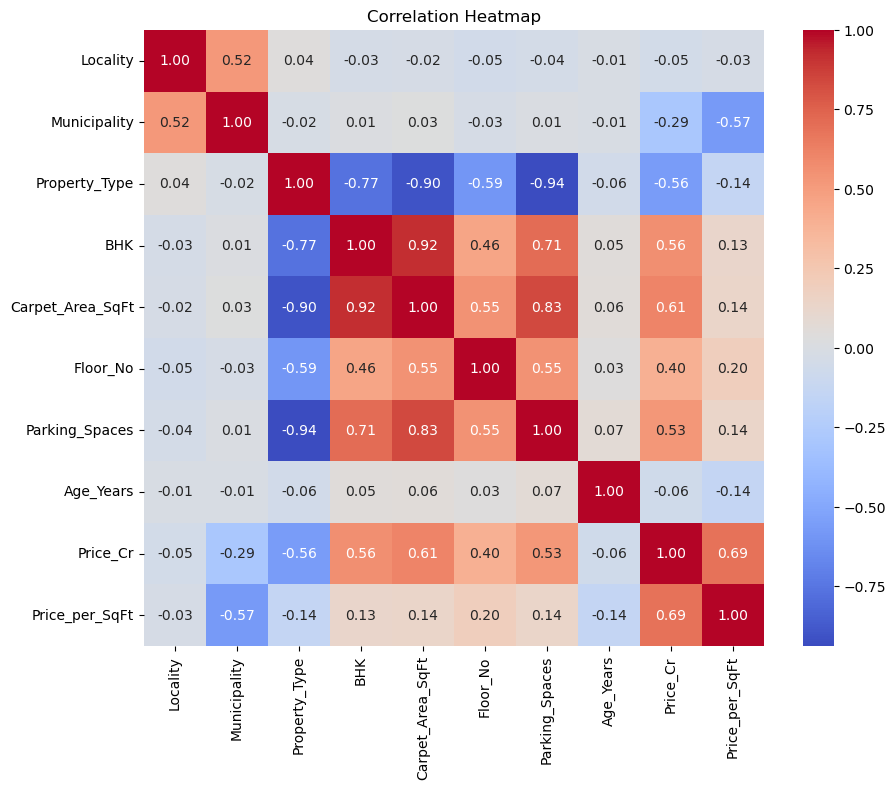

Root Mean Squared Error (RMSE): 4.1784


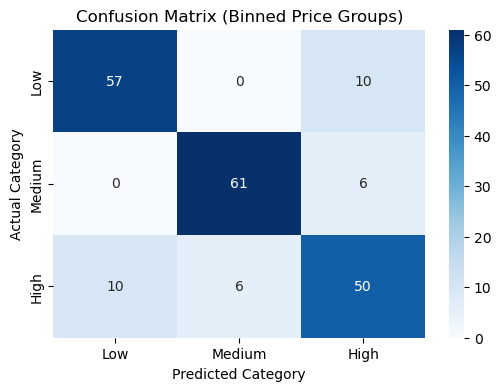

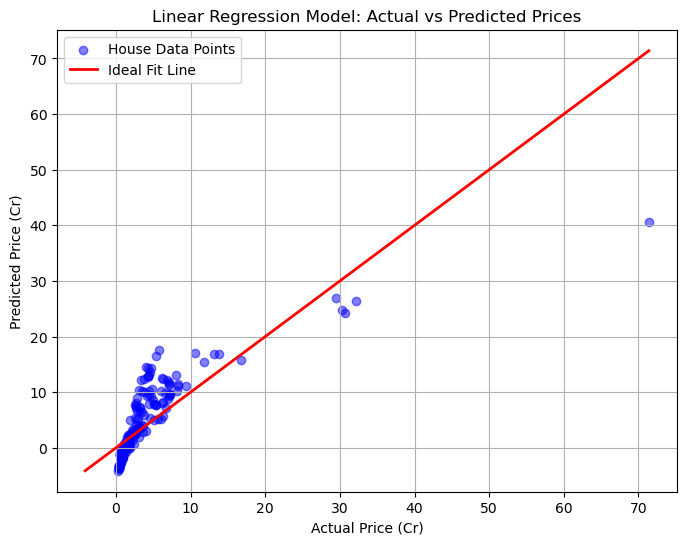

All steps completed successfully.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# --- STEP 1: DATA CLEANING ---
# Load the dataset
df = pd.read_csv('cleaned_dataset.csv')

# Removing whitespace from strings in all columns
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Encoding categorical text data (Locality, Municipality, etc.) into numbers
le = LabelEncoder()
df_encoded = df.copy()
categorical_cols = ['Locality', 'Municipality', 'Property_Type']
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df[col])

# --- STEP 3: DO CORRELATION ---
plt.figure(figsize=(10, 8))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Preparing Features (X) and Target (y) for the model
X = df_encoded.drop('Price_Cr', axis=1) # All columns except Price
y = df_encoded['Price_Cr']             # The value we want to predict

# Splitting data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- STEP 2, 6 & 10: USE REGRESSION MODEL, FINALIZE, & MAKE THE MODEL FIT ---
model = LinearRegression()
model.fit(X_train, y_train)

# --- STEP 7: PREDICT VALUES ---
y_pred = model.predict(X_test)

# --- STEP 8: CHECK RMSE ---
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# --- STEP 9: DO CONFUSION MATRIX ---
# Since this is regression, we group prices into 'Low', 'Medium', and 'High' categories
# to create the matrix as per your step requirement.
y_test_binned = pd.qcut(y_test, q=3, labels=['Low', 'Medium', 'High'])
y_pred_binned = pd.qcut(y_pred, q=3, labels=['Low', 'Medium', 'High'])

cm = confusion_matrix(y_test_binned, y_pred_binned)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Medium', 'High'], 
            yticklabels=['Low', 'Medium', 'High'])
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.title('Confusion Matrix (Binned Price Groups)')
plt.show()

# --- LINEAR REGRESSION GRAPH (Actual vs Predicted) ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='House Data Points')
# Adding a 45-degree diagonal line (Perfect Prediction Line)
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, label='Ideal Fit Line')
plt.xlabel('Actual Price (Cr)')
plt.ylabel('Predicted Price (Cr)')
plt.title('Linear Regression Model: Actual vs Predicted Prices')
plt.legend()
plt.grid(True)
plt.show()

print("All steps completed successfully.")